Example 1: Fixed-Point Method


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Using g1(x) = 1 - x^3:
Did not converge within the maximum number of iterations

Using g2(x) = (1-x)^(1/3):
Converged to 0.6823281783 in 39 iterations
f(x) = 8.9748140564e-07


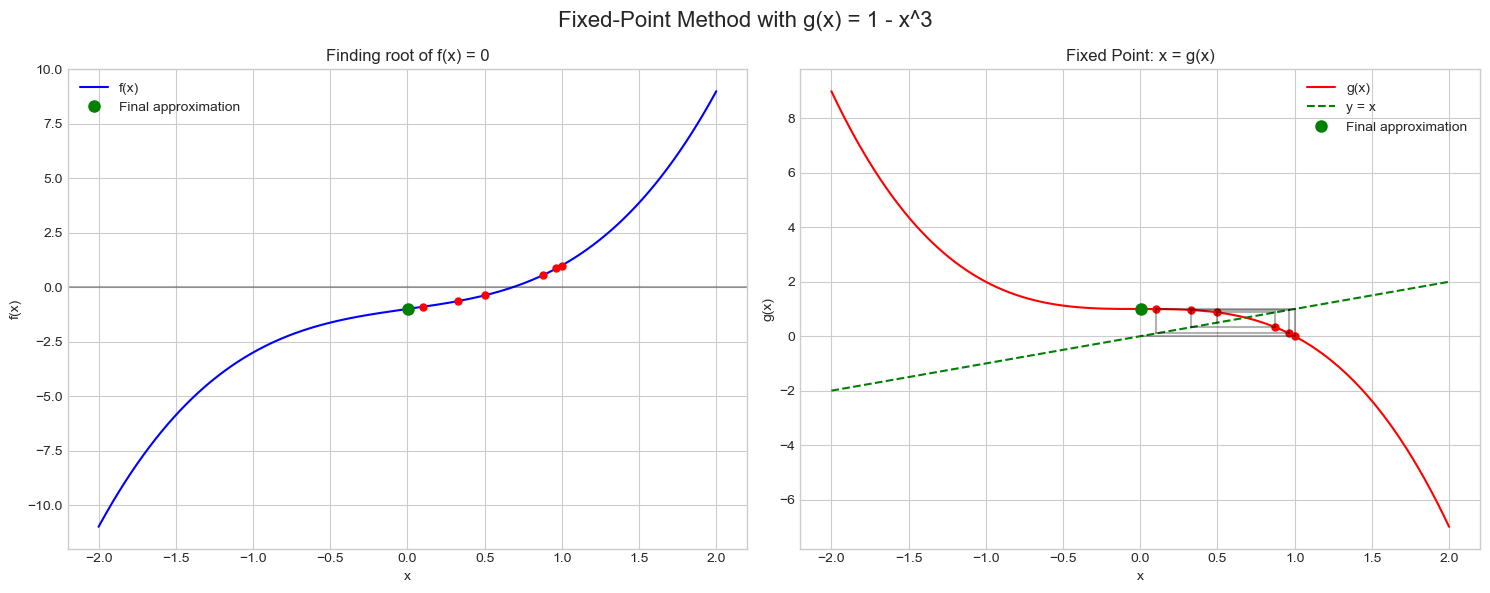

/tmp/ipykernel_1905104/3727277452.py:239: RuntimeWarning: invalid value encountered in power
  g2_example1 = lambda x: (1 - x)**(1/3)


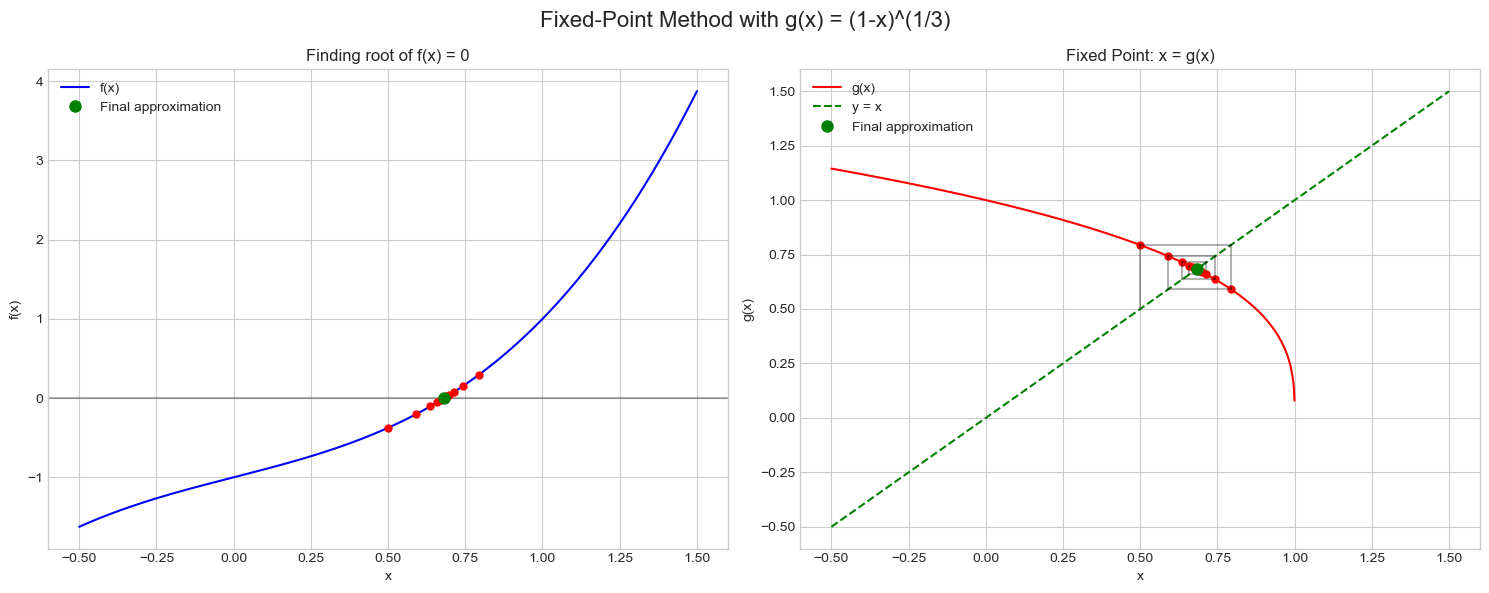


Convergence Discussion:
For the fixed-point method to converge, we need |g'(x)| < 1 in the neighborhood of the root.
For g1(x) = 1 - x^3, g1'(x) = -3x^2, which is not < 1 in magnitude near the root.
For g2(x) = (1-x)^(1/3), g2'(x) = -(1/3)(1-x)^(-2/3), which can be < 1 in magnitude.


Example 2: Newton's Method


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Converged to 0.6823278038 in 4 iterations
f(x) = 7.8559381222e-13


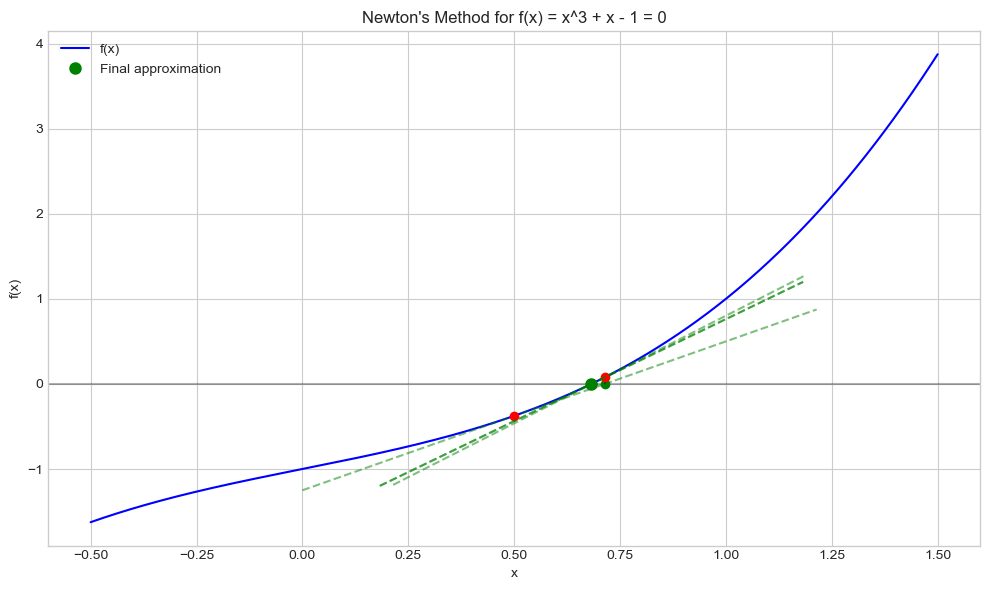



Example 3: Comparison on a challenging function


<IPython.core.display.Math object>

<IPython.core.display.Math object>


Fixed-Point Method:
Converged to 1.3768784946 in 7 iterations
f(x) = -2.7022051641e-07

Newton's Method:
Converged to 1.3768785701 in 5 iterations
f(x) = 5.3645976550e-13


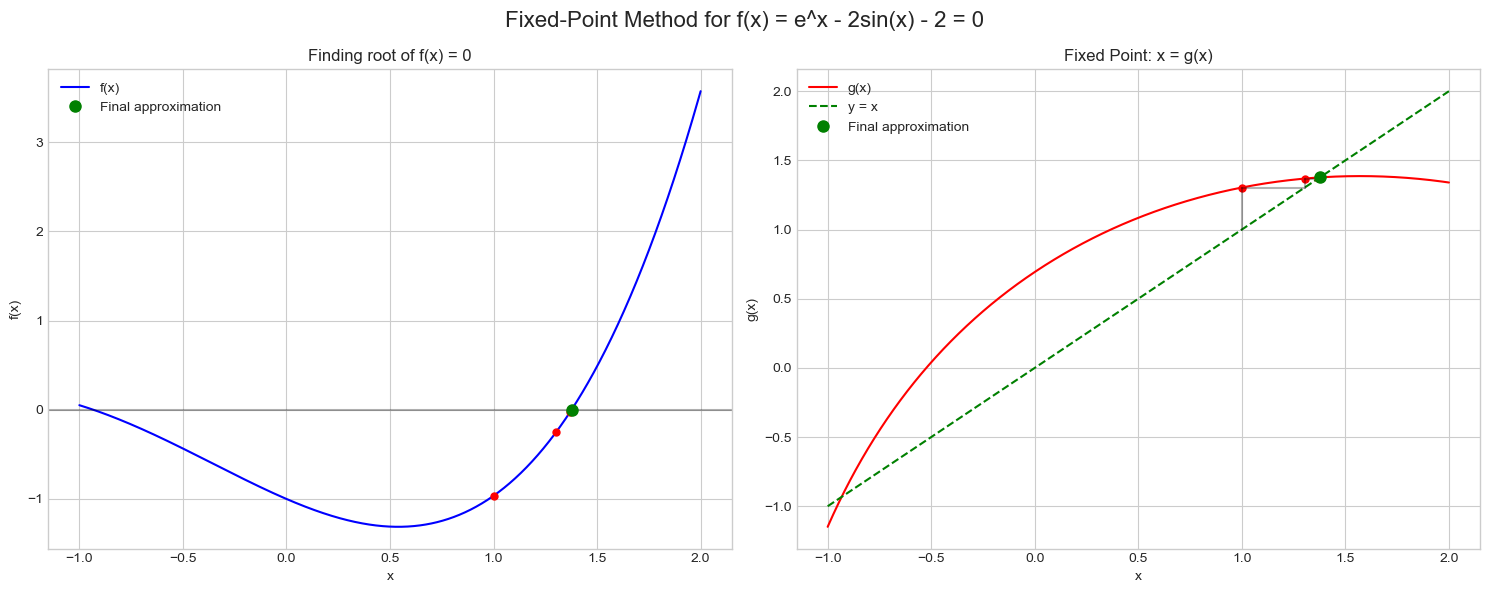

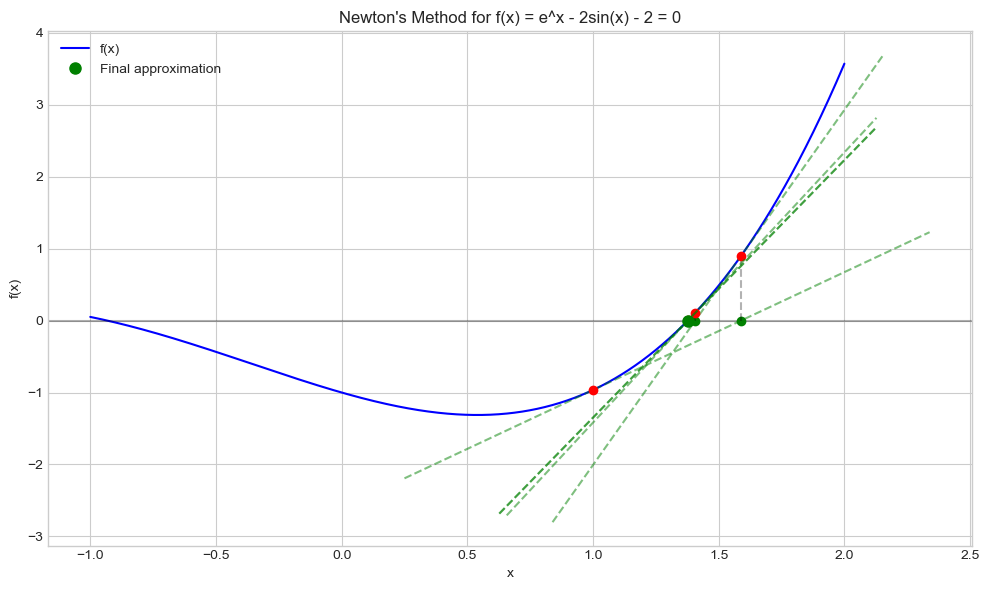



Comparison of Fixed-Point Method and Newton's Method
Fixed-Point Method:
  + Simpler to implement and understand
  + Does not require the derivative of the function
  - Generally slower convergence (linear)
  - Requires rewriting the equation as x = g(x) where |g'(x)| < 1
  - May not converge if g(x) is not chosen carefully

Newton's Method:
  + Faster convergence (quadratic) near the root
  + Often requires fewer iterations
  - Requires calculating the derivative
  - More computationally intensive per iteration
  - Can fail if f'(x) is close to zero
  - Sensitive to the initial guess

Convergence rate comparison:



| Method | Convergence Rate | Error Relation |
|--------|-----------------|----------------|
| Fixed-Point | Linear | $|e_{n+1}| \approx K |e_n|$ for some constant $K < 1$ |
| Newton | Quadratic | $|e_{n+1}| \approx K |e_n|^2$ for some constant $K$ |



Effect of tolerance on iteration count for f(x) = x^3 + x - 1 = 0, starting at x0 = 0.5:

| Tolerance | Fixed-Point Iterations | Newton Iterations |
|-----------|--------------------------|-------------------|
| 1.0e-02 |            12            |         3         |
| 1.0e-04 |            25            |         4         |
| 1.0e-06 |            39            |         4         |
| 1.0e-08 |            53            |         5         |
| 1.0e-10 |            67            |         5         |
| 1.0e-12 |            81            |         5         |

Creating animation of Newton's method (may take a moment)...

Conclusion: When to use which method?
Fixed-Point Method is preferable when:
  - The derivative is complicated or expensive to compute
  - You can find a g(x) with |g'(x)| < 1 near the root
  - You need a simple, robust method

Newton's Method is preferable when:
  - You need fast convergence
  - The derivative is readily available and not zero near the root
  - You hav

In [1]:
# Numerical Methods for Solving Nonlinear Equations
# Based on Burden's Numerical Analysis

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, Math, Markdown

# Utility function to display equations nicely
def display_equation(eq_str):
    display(Math(eq_str))
    
# Plot configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# ======================================================
# Part 1: Fixed-Point Iteration Method
# ======================================================

def fixed_point_method(g, x0, tol=1e-6, max_iter=100):
    """
    Fixed-point iteration method to find x such that x = g(x)
    
    Parameters:
    -----------
    g : function
        The function in the form x = g(x)
    x0 : float
        Initial guess
    tol : float
        Error tolerance
    max_iter : int
        Maximum number of iterations
        
    Returns:
    --------
    x_values : list
        List of approximations
    converged : bool
        Whether the method converged
    """
    x_values = [x0]
    converged = False
    
    for i in range(max_iter):
        x_new = g(x_values[-1])
        x_values.append(x_new)
        
        if abs(x_new - x_values[-2]) < tol:
            converged = True
            break
            
    return x_values, converged

def visualize_fixed_point(f, g, a, b, x_values, title):
    """
    Visualize the fixed-point iteration method
    
    Parameters:
    -----------
    f : function
        Original function f(x) = 0
    g : function
        Transformed function x = g(x)
    a, b : float
        Interval for plotting
    x_values : list
        List of approximations from fixed_point_method
    title : str
        Plot title
    """
    x = np.linspace(a, b, 1000)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot f(x) vs x on the first subplot
    ax1.plot(x, f(x), 'b-', label='f(x)')
    ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax1.set_xlabel('x')
    ax1.set_ylabel('f(x)')
    ax1.set_title('Finding root of f(x) = 0')
    ax1.grid(True)
    ax1.legend()
    
    # Plot g(x) vs x on the second subplot
    ax2.plot(x, g(x), 'r-', label='g(x)')
    ax2.plot(x, x, 'g--', label='y = x')
    ax2.set_xlabel('x')
    ax2.set_ylabel('g(x)')
    ax2.set_title('Fixed Point: x = g(x)')
    ax2.grid(True)
    ax2.legend()
    
    # Mark iterations on both plots
    for i in range(len(x_values) - 1):
        # Mark on f(x) plot
        ax1.plot(x_values[i], f(x_values[i]), 'ro', markersize=5)
        
        # Mark on g(x) plot and show the iteration path
        ax2.plot(x_values[i], g(x_values[i]), 'ro', markersize=5)
        ax2.plot([x_values[i], x_values[i]], [x_values[i], g(x_values[i])], 'k-', alpha=0.3)
        ax2.plot([x_values[i], x_values[i+1]], [g(x_values[i]), g(x_values[i])], 'k-', alpha=0.3)
    
    # Mark the final approximation
    ax1.plot(x_values[-1], f(x_values[-1]), 'go', markersize=8, label='Final approximation')
    ax2.plot(x_values[-1], g(x_values[-1]), 'go', markersize=8, label='Final approximation')
    
    ax1.legend()
    ax2.legend()
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# ======================================================
# Part 2: Newton's Method
# ======================================================

def newton_method(f, df, x0, tol=1e-6, max_iter=100):
    """
    Newton's method to find roots of f(x) = 0
    
    Parameters:
    -----------
    f : function
        The function whose root we want to find
    df : function
        Derivative of f
    x0 : float
        Initial guess
    tol : float
        Error tolerance
    max_iter : int
        Maximum number of iterations
        
    Returns:
    --------
    x_values : list
        List of approximations
    converged : bool
        Whether the method converged
    """
    x_values = [x0]
    converged = False
    
    for i in range(max_iter):
        # Check if derivative is close to zero to avoid division by zero
        if abs(df(x_values[-1])) < 1e-10:
            break
            
        x_new = x_values[-1] - f(x_values[-1]) / df(x_values[-1])
        x_values.append(x_new)
        
        if abs(x_new - x_values[-2]) < tol:
            converged = True
            break
            
    return x_values, converged

def visualize_newton(f, df, a, b, x_values, title):
    """
    Visualize Newton's method
    
    Parameters:
    -----------
    f : function
        The function whose root we want to find
    df : function
        Derivative of f
    a, b : float
        Interval for plotting
    x_values : list
        List of approximations from newton_method
    title : str
        Plot title
    """
    x = np.linspace(a, b, 1000)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot f(x)
    ax.plot(x, f(x), 'b-', label='f(x)')
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(title)
    ax.grid(True)
    
    # Plot tangent lines and mark points
    for i in range(len(x_values) - 1):
        # Current point
        xi = x_values[i]
        fxi = f(xi)
        
        # Tangent line: y - f(xi) = f'(xi)(x - xi)
        # Simplified: y = f'(xi)(x - xi) + f(xi)
        def tangent_line(x):
            return df(xi) * (x - xi) + fxi
        
        # Next x-value is where tangent line crosses x-axis
        # For visualization purposes, extend tangent line a bit
        tangent_x = np.linspace(xi - (b-a)/4, x_values[i+1] + (b-a)/4, 100)
        ax.plot(tangent_x, tangent_line(tangent_x), 'g--', alpha=0.5)
        
        # Mark current point
        ax.plot(xi, fxi, 'ro', markersize=6)
        
        # Mark next x on x-axis
        ax.plot(x_values[i+1], 0, 'go', markersize=6)
        
        # Draw vertical line to the x-axis
        ax.plot([x_values[i+1], x_values[i+1]], [0, f(x_values[i+1])], 'k--', alpha=0.3)
    
    # Mark the final approximation
    ax.plot(x_values[-1], f(x_values[-1]), 'go', markersize=8, label='Final approximation')
    
    ax.legend()
    plt.tight_layout()
    plt.show()

# ======================================================
# Example 1: Fixed-Point Method
# ======================================================

# Let's demonstrate with f(x) = x^3 + x - 1 = 0
print("Example 1: Fixed-Point Method")
display_equation(r"f(x) = x^3 + x - 1 = 0")

# We need to rewrite this as x = g(x)
# x = 1 - x^3 is one way, but might not converge.
# Let's try x = (1-x^3)^(1/3) as g(x)
display_equation(r"g_1(x) = 1 - x^3")
display_equation(r"g_2(x) = \sqrt[3]{1 - x}")

# Define the original function and two possible g(x) functions
f_example1 = lambda x: x**3 + x - 1
g1_example1 = lambda x: 1 - x**3
g2_example1 = lambda x: (1 - x)**(1/3)

# Initial guess
x0 = 0.5

# Apply fixed-point method with g1
print("\nUsing g1(x) = 1 - x^3:")
x_values_g1, converged_g1 = fixed_point_method(g1_example1, x0)

if converged_g1:
    print(f"Converged to {x_values_g1[-1]:.10f} in {len(x_values_g1)-1} iterations")
    print(f"f(x) = {f_example1(x_values_g1[-1]):.10e}")
else:
    print("Did not converge within the maximum number of iterations")
    
# Apply fixed-point method with g2
print("\nUsing g2(x) = (1-x)^(1/3):")
x_values_g2, converged_g2 = fixed_point_method(g2_example1, x0)

if converged_g2:
    print(f"Converged to {x_values_g2[-1]:.10f} in {len(x_values_g2)-1} iterations")
    print(f"f(x) = {f_example1(x_values_g2[-1]):.10e}")
else:
    print("Did not converge within the maximum number of iterations")

# Visualize the results for g1
visualize_fixed_point(f_example1, g1_example1, -2, 2, x_values_g1[:7], 
                      "Fixed-Point Method with g(x) = 1 - x^3")

# Visualize the results for g2
visualize_fixed_point(f_example1, g2_example1, -0.5, 1.5, x_values_g2, 
                      "Fixed-Point Method with g(x) = (1-x)^(1/3)")

# Discussion of convergence conditions
print("\nConvergence Discussion:")
print("For the fixed-point method to converge, we need |g'(x)| < 1 in the neighborhood of the root.")
print("For g1(x) = 1 - x^3, g1'(x) = -3x^2, which is not < 1 in magnitude near the root.")
print("For g2(x) = (1-x)^(1/3), g2'(x) = -(1/3)(1-x)^(-2/3), which can be < 1 in magnitude.")

# ======================================================
# Example 2: Newton's Method
# ======================================================

print("\n\nExample 2: Newton's Method")
display_equation(r"f(x) = x^3 + x - 1 = 0")
display_equation(r"f'(x) = 3x^2 + 1")

# Define the function and its derivative
f_example2 = lambda x: x**3 + x - 1
df_example2 = lambda x: 3*x**2 + 1

# Initial guess
x0 = 0.5

# Apply Newton's method
x_values_newton, converged_newton = newton_method(f_example2, df_example2, x0)

if converged_newton:
    print(f"Converged to {x_values_newton[-1]:.10f} in {len(x_values_newton)-1} iterations")
    print(f"f(x) = {f_example2(x_values_newton[-1]):.10e}")
else:
    print("Did not converge within the maximum number of iterations")

# Visualize Newton's method
visualize_newton(f_example2, df_example2, -0.5, 1.5, x_values_newton, 
                 "Newton's Method for f(x) = x^3 + x - 1 = 0")

# ======================================================
# Example 3: Comparison with a challenging function
# ======================================================

print("\n\nExample 3: Comparison on a challenging function")
display_equation(r"f(x) = e^x - 2\sin(x) - 2 = 0")
display_equation(r"f'(x) = e^x - 2\cos(x)")

# Define the function and its derivative
f_example3 = lambda x: np.exp(x) - 2*np.sin(x) - 2
df_example3 = lambda x: np.exp(x) - 2*np.cos(x)

# For fixed-point, rewrite as x = g(x): x = ln(2 + 2sin(x))
g_example3 = lambda x: np.log(2 + 2*np.sin(x))

# Initial guess
x0 = 1.0

# Apply fixed-point method
print("\nFixed-Point Method:")
x_values_fp, converged_fp = fixed_point_method(g_example3, x0)

if converged_fp:
    print(f"Converged to {x_values_fp[-1]:.10f} in {len(x_values_fp)-1} iterations")
    print(f"f(x) = {f_example3(x_values_fp[-1]):.10e}")
else:
    print("Did not converge within the maximum number of iterations")

# Apply Newton's method
print("\nNewton's Method:")
x_values_newton3, converged_newton3 = newton_method(f_example3, df_example3, x0)

if converged_newton3:
    print(f"Converged to {x_values_newton3[-1]:.10f} in {len(x_values_newton3)-1} iterations")
    print(f"f(x) = {f_example3(x_values_newton3[-1]):.10e}")
else:
    print("Did not converge within the maximum number of iterations")

# Visualize fixed-point method
visualize_fixed_point(f_example3, g_example3, -1, 2, x_values_fp, 
                      "Fixed-Point Method for f(x) = e^x - 2sin(x) - 2 = 0")

# Visualize Newton's method
visualize_newton(f_example3, df_example3, -1, 2, x_values_newton3, 
                 "Newton's Method for f(x) = e^x - 2sin(x) - 2 = 0")

# ======================================================
# Comparison of methods
# ======================================================

print("\n\nComparison of Fixed-Point Method and Newton's Method")
print("======================================================")
print("Fixed-Point Method:")
print("  + Simpler to implement and understand")
print("  + Does not require the derivative of the function")
print("  - Generally slower convergence (linear)")
print("  - Requires rewriting the equation as x = g(x) where |g'(x)| < 1")
print("  - May not converge if g(x) is not chosen carefully")
print("\nNewton's Method:")
print("  + Faster convergence (quadratic) near the root")
print("  + Often requires fewer iterations")
print("  - Requires calculating the derivative")
print("  - More computationally intensive per iteration")
print("  - Can fail if f'(x) is close to zero")
print("  - Sensitive to the initial guess")

print("\nConvergence rate comparison:")
display(Markdown("""
| Method | Convergence Rate | Error Relation |
|--------|-----------------|----------------|
| Fixed-Point | Linear | $|e_{n+1}| \\approx K |e_n|$ for some constant $K < 1$ |
| Newton | Quadratic | $|e_{n+1}| \\approx K |e_n|^2$ for some constant $K$ |
"""))

# Example showing how iteration count changes with tolerance
tolerances = [1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12]

print("\nEffect of tolerance on iteration count for f(x) = x^3 + x - 1 = 0, starting at x0 = 0.5:")
print("\n| Tolerance | Fixed-Point Iterations | Newton Iterations |")
print("|-----------|--------------------------|-------------------|")

for tol in tolerances:
    x_fp, _ = fixed_point_method(g2_example1, 0.5, tol=tol)
    x_newton, _ = newton_method(f_example2, df_example2, 0.5, tol=tol)
    print(f"| {tol:.1e} | {len(x_fp)-1:^24} | {len(x_newton)-1:^17} |")

# ======================================================
# Interactive animation for teaching (bonus)
# ======================================================

def create_newton_animation(f, df, x0, a, b, tol=1e-6, max_iter=20):
    """Create an animation of Newton's method"""
    x_values, _ = newton_method(f, df, x0, tol=tol, max_iter=max_iter)
    
    x = np.linspace(a, b, 1000)
    y = f(x)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot the function
    line, = ax.plot(x, y, 'b-', label='f(x)')
    # Plot the x-axis
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    
    # For animation
    tangent_line, = ax.plot([], [], 'g--', label='Tangent line')
    current_point, = ax.plot([], [], 'ro', markersize=8, label='Current point')
    next_point, = ax.plot([], [], 'go', markersize=8, label='Next approximation')
    
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title("Newton's Method Animation")
    ax.set_xlim(a, b)
    ax.set_ylim(min(y) - 0.5, max(y) + 0.5)
    ax.grid(True)
    ax.legend()
    
    text = ax.text(0.05, 0.95, '', transform=ax.transAxes, 
                   verticalalignment='top', fontsize=12)
    
    def init():
        tangent_line.set_data([], [])
        current_point.set_data([], [])
        next_point.set_data([], [])
        text.set_text('')
        return tangent_line, current_point, next_point, text
    
    def update(frame):
        if frame < len(x_values) - 1:
            # Current point
            xi = x_values[frame]
            fxi = f(xi)
            dfxi = df(xi)
            
            # Tangent line
            xrange = np.linspace(xi - (b-a)/4, xi + (b-a)/4, 100)
            yrange = fxi + dfxi * (xrange - xi)
            
            tangent_line.set_data(xrange, yrange)
            current_point.set_data(xi, fxi)
            next_point.set_data(x_values[frame+1], 0)
            
            text.set_text(f'Iteration {frame+1}\n'
                          f'x_{frame} = {xi:.6f}\n'
                          f'f(x_{frame}) = {fxi:.6f}\n'
                          f'f\'(x_{frame}) = {dfxi:.6f}\n'
                          f'x_{frame+1} = x_{frame} - f(x_{frame})/f\'(x_{frame}) = {x_values[frame+1]:.6f}')
        else:
            # Show final result
            text.set_text(f'Converged in {frame} iterations\n'
                         f'Root: x = {x_values[-1]:.10f}\n'
                         f'f(x) = {f(x_values[-1]):.10e}')
        
        return tangent_line, current_point, next_point, text
    
    ani = FuncAnimation(fig, update, frames=len(x_values), init_func=init, 
                        blit=True, interval=1000, repeat_delay=2000)
    
    plt.close()  # To prevent the static figure from being displayed twice
    return ani

# Create animation for teaching
print("\nCreating animation of Newton's method (may take a moment)...")
newton_animation = create_newton_animation(f_example2, df_example2, 0.5, -0.5, 1.5)

# In a Jupyter notebook, you would display it as:
# from IPython.display import HTML
# HTML(newton_animation.to_jshtml())

# ======================================================
# Conclusion
# ======================================================

print("\nConclusion: When to use which method?")
print("======================================================")
print("Fixed-Point Method is preferable when:")
print("  - The derivative is complicated or expensive to compute")
print("  - You can find a g(x) with |g'(x)| < 1 near the root")
print("  - You need a simple, robust method")
print("\nNewton's Method is preferable when:")
print("  - You need fast convergence")
print("  - The derivative is readily available and not zero near the root")
print("  - You have a good initial guess close to the root")
print("  - You're solving a system where computational efficiency is important")